# Project 3 - Lab 1 - Data Visualization with NHTS

In [3]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

%pip install matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set a clean visual style for all our plots
# seaborn styles make plots look more professional with minimal effort
sns.set_style('whitegrid')
sns.set_palette('deep')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Lab Activity #1: Show data is correctly loaded
First, let us refresh our memories and load in the data needed for this session. Load in your National Household Travel Survey (NHTS) data.

In [6]:
#### Load in the data in csv
nhts_data = pd.read_csv('NHTS(in).csv')
 # importing the national household travel survey

# Perform the previously learned techniques to visualize the head, tail, columns, and print the data 
nhts_data

,household_id,census_division,census_region,driver_count,household_income,household_size,household_workers,home_type,household_location,number_adults_household,...,urban,vehicle_type,hybrid,make,vehicle_age,vehicle_commercial,vehicle_delivery,vehicle_rideshare,fuel_type,vehicle_year
0,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,7,No,NaN,NaN,Gas,2015
1,9000013002,New England,Northeast,2,"$175,000 or more",4,1,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Subaru,3,No,NaN,NaN,Gas,2019
2,9000013016,New England,Northeast,2,"$75,000 to $99,999",2,2,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Toyota,11,No,NaN,NaN,Gas,2011
3,9000013039,New England,Northeast,2,"$75,000 to $99,999",4,1,Building with 2 or more apartments,Urban,2,...,In an urban area,Automobile/car/stationwagon,No,Nissan/Datsun,7,No,NaN,NaN,Gas,2015
4,9000013041,New England,Northeast,1,"$175,000 or more",1,1,"Townhome, Condo",Urban,1,...,In an urban area,Automobile/car/stationwagon,No,BMV,8,No,NaN,NaN,Gas,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14679,9000218013,East South Central,South,1,"$15,000 to $24,999",2,0,One-family detached,Urban,2,...,In an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Volkswagen,4,No,NaN,NaN,Gas,2018
14680,9000218021,East South Central,South,1,"$25,000 to $34,999",1,0,One-family detached,Rural,1,...,Not in an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Ford,6,Yes,No,No,Gas,2016
14681,9000218034,East South Central,South,2,"$25,000 to $34,999",2,0,One-family detached,Rural,2,...,Not in an urban area,"SUV (Santa Fe, Tahoe, Jeep, etc.)",No,Honda,4,No,NaN,NaN,Gas,2018
14682,9000218034,East South Central,South,2,"$25,000 to $34,999",2,0,One-family detached,Rural,2,...,Not in an urban area,Pickup Truck,No,Toyota,19,No,NaN,NaN,Gas,2003


### Lab Activity #2: Understanding the Data

Now, I want you to take some time to open the NHTS data in excel, study it and understand what information it carries. Read all column names and understand them.
1. Think about potential data visualization plots that can help you understand the data
2. Think about relationships between different data columns
3. Report in the markdown below, your insights

In [1]:
# Report here some insights you got after looking through the data
#1. Geographic Data
#2. Economic data (household income)
#3. Samples include multiple manufacturers
#4. Households vary in number of adults 



## Exploring the Data with Descriptive Statistics

Before we jump into plotting, it is always good practice to explore the data numerically. Descriptive statistics give us a quick summary of what the data looks like — the mean, spread, and range of values. This helps us choose the right type of plot later.

We use `.describe()` to get statistics for numerical columns and `.value_counts()` to see the frequency of categorical variables.

In [4]:
# Use .describe() to get summary statistics for all numeric columns

# This tells us the count, mean, std, min, max, and quartiles

nhts_data.describe()

,household_id,driver_count,household_size,household_workers,number_adults_household,vehicles_per_household,travel_date,vehicle_age,vehicle_year
count,1.468400e+04,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000,14684.000000
mean,9.000113e+09,2.014165,2.558090,1.179447,2.061223,2.534323,202211.722623,10.174271,2011.866658
std,5.936829e+04,0.814926,1.333751,0.984043,0.812286,1.436046,20.578951,7.959353,8.009252
min,9.000013e+09,0.000000,1.000000,0.000000,1.000000,1.000000,202201.000000,1.000000,1982.000000
25%,9.000057e+09,2.000000,2.000000,0.000000,2.000000,2.000000,202204.000000,4.000000,2007.000000
50%,9.000107e+09,2.000000,2.000000,1.000000,2.000000,2.000000,202208.000000,8.000000,2014.000000
75%,9.000166e+09,2.000000,3.000000,2.000000,2.000000,3.000000,202211.000000,15.000000,2018.000000
max,9.000218e+09,7.000000,10.000000,6.000000,8.000000,17.000000,202301.000000,40.000000,2023.000000


In [7]:
# Use .value_counts() to see how many of each vehicle make are in the data
# This is useful for understanding categorical variables before plotting
nhts_data['make'].value_counts()

nhts_data['household_income'].value_counts()

nhts_data['travel_day'].value_counts()

travel_day
Monday       2698
Sunday       2589
Tuesday      2084
Friday       1977
Thursday     1943
Wednesday    1819
Saturday     1574
Name: count, dtype: int64

In [8]:
# Let's also check for missing values — this is important before plotting!
# Missing values can cause errors or misleading graphs

nhts_data.isnull().sum()

household_id                   0
census_division                0
census_region                  0
driver_count                   0
household_income               0
household_size                 0
household_workers              0
home_type                      0
household_location             0
number_adults_household        0
vehicles_per_household         0
travel_date                    0
travel_day                     0
urban                          0
vehicle_type                   0
hybrid                         0
make                         116
vehicle_age                    0
vehicle_commercial            39
vehicle_delivery           13491
vehicle_rideshare          13487
fuel_type                     32
vehicle_year                   0
dtype: int64

## Basics of Graphing in Python using matplotlib

Matplotlib documentation: https://matplotlib.org/stable/index.html 

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations. We will learn how to make plots using the matplotlib packages in this course and the above link is a great resource for troubleshooting plots!

We will also use **seaborn**, which is built on top of matplotlib and provides a higher-level interface for drawing attractive statistical graphics. Seaborn documentation: https://seaborn.pydata.org/

What we need to tell Python in order to get a plot:
1. Tell Python that we are creating a figure
2. Tell Python what type of plot we want to create (scatter, bar, etc.)
3. Tell Python what dataframe we are plotting
4. Tell Python what data goes on each axis
5. Tell Python to show the plot

### Practice Graphs

Now that we know the basics of plotting in Python, let's try creating several different types of plots (which incidentally, you may need for Project #3....  :) Each of these plots is used for a different reason and requires a specific type of data. As a result, each plot looks slightly different in both code and final result. On Canvas, you have access to "matplotlib" cheatsheets that can help you get started if you need help!

#### Countplot

Before diving into more complex plots, let's start with something simple — a **countplot**. A countplot shows how many observations exist in each category. This is one of the simplest but most useful plots to understand your data.

Let's see how many vehicles of each type are in our dataset.

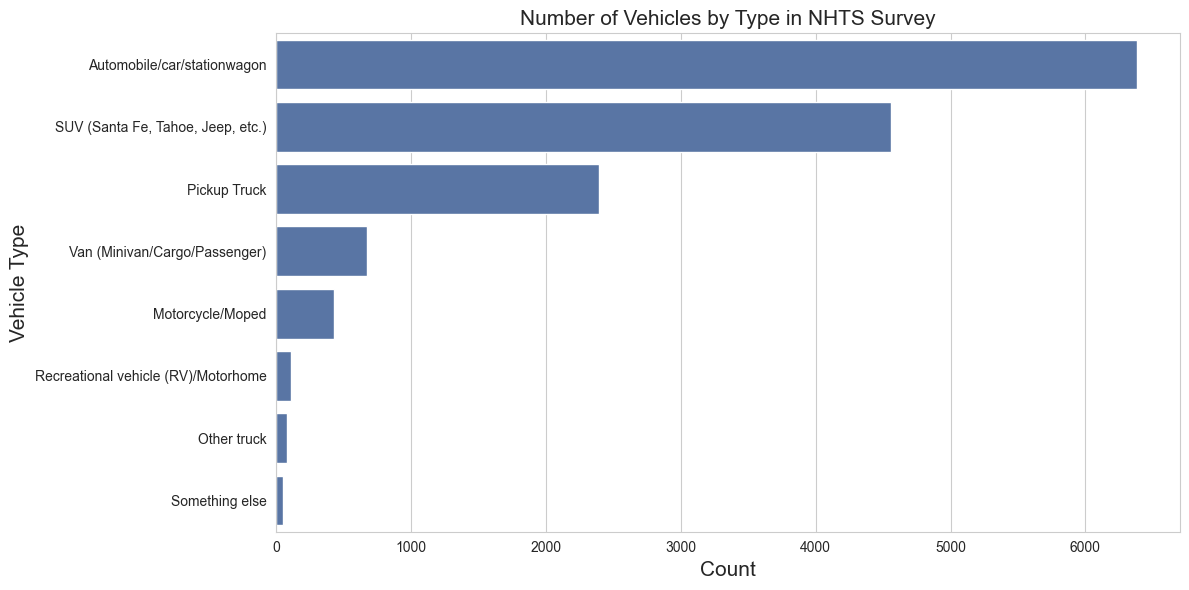

In [10]:
# Create a countplot showing the number of each vehicle type
# seaborn's countplot automatically counts the categories for you

## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize = (12,6))

## Step 2: use sns.countplot to create the plot
# hint: sns.countplot(data=..., x=...) or sns.countplot(data=..., y=...) for horizontal
sns.countplot(data = nhts_data, y = 'vehicle_type', order = nhts_data['vehicle_type'].value_counts().index) 

## Step 3: add labels and title
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Vehicle Type', fontsize = 15)
plt.title('Number of Vehicles by Type in NHTS Survey', fontsize = 15)

## Step 4: show the plot
plt.tight_layout()
plt.show()

### Lab Activity #3
#Analyze the countplot and state at least two observations:
#1. Passenger vehicles dominate the dataset

#2. Specialty and recreational vehicles are relatively rare

#### Boxplot

Boxplots show the distribution of one variable, including the median (50th percentile) and the 25th and 75th percentiles. On a boxplot, the middle of the box is bisected with a line, representing the median. The top edge of the box is the 75th percentile and the bottom edge of the box is the 25th percentile. The whiskers (lines) that extend from the box show the top and bottom range of the data. The individual dots beyond the whiskers are **outliers**.

In Python (and many other coding languages), packages like matplotlib have built in functions that understand how to construct boxplots. As a result, you need to choose a variable to plot. 

Note, you need one variable to be continuous, not discrete! Let's try making a boxplot of vehicle ages by vehicle make.

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 2000x2000 with 0 Axes>

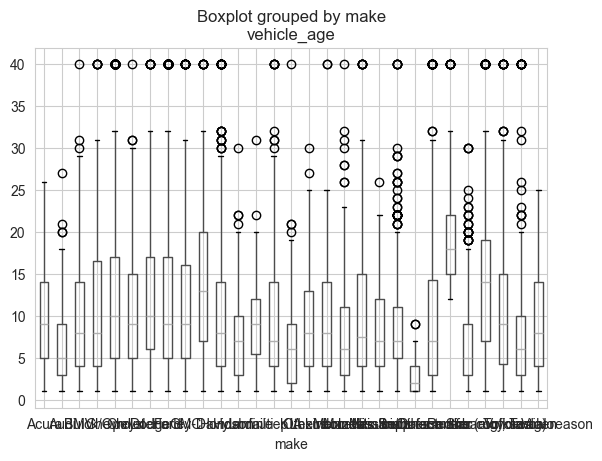

In [13]:
# Let us create a boxplot to visualize vehicle ages by vehicle make. Below are general steps we take to create plots in python

## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (20,20))


## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'make')


## Step 3: tell python to show the plot
plt.show


Yay! Our very first boxplot and plot in Python! You'll notice that Python plots with a series of 'base' features: the color is blue and black, the axes are not rotated unless we want them to be and Python uses a specific font. You can change all of these features using some of the `matplotlib` functions and some of the functions in `seaborn` as well. Be careful though about mixing and matching as sometimes functions from `matplotlib` and `seaborn` are not designed to be used together! Let's try some customization of our boxplot below to check this out.

<Figure size 2000x2000 with 0 Axes>

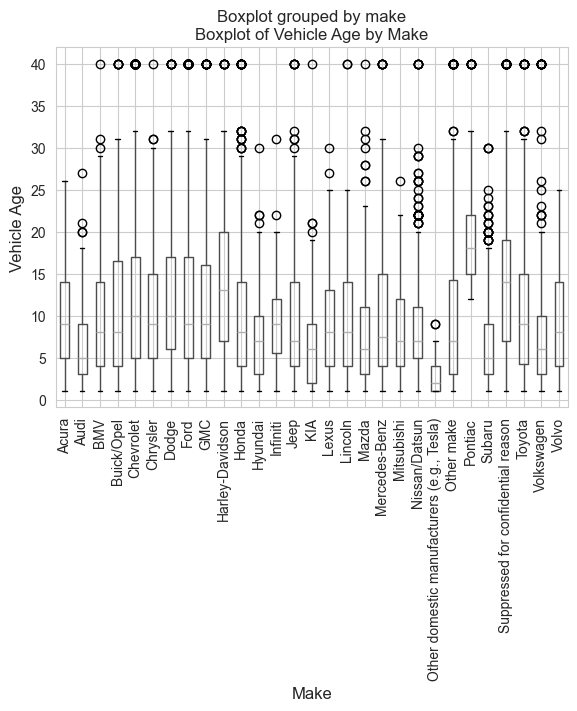

In [16]:
## Let us re-plot the Boxplot and add some customization to it

## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (20,20))


## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'make')

## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read
plt.xticks(rotation = 90)

### the next two lines create your axis labels
plt.xlabel('Make', fontsize = 12)
plt.ylabel('Vehicle Age', fontsize = 12)

### this line gives your plot a title
plt.title('Boxplot of Vehicle Age by Make', fontsize = 12)

## Step 4: tell python to show the plot

plt.show()

### Lab Activity #4
#Analyze the plot and state at least three different conclusions/information you gather from the plot
#1. My Car will hopefully last me another 15 years :)

#2. Vehicle age distributions are fairly similar across most brands

#3. There are many older outliers across nearly all makes


#### Violin Plot

A **violin plot** is similar to a boxplot, but it also shows the full distribution shape of the data using a kernel density estimate (KDE). The wider the violin, the more data points exist at that value. This gives us more information than a boxplot alone.

Let's compare vehicle ages for Urban vs Rural households using a violin plot.

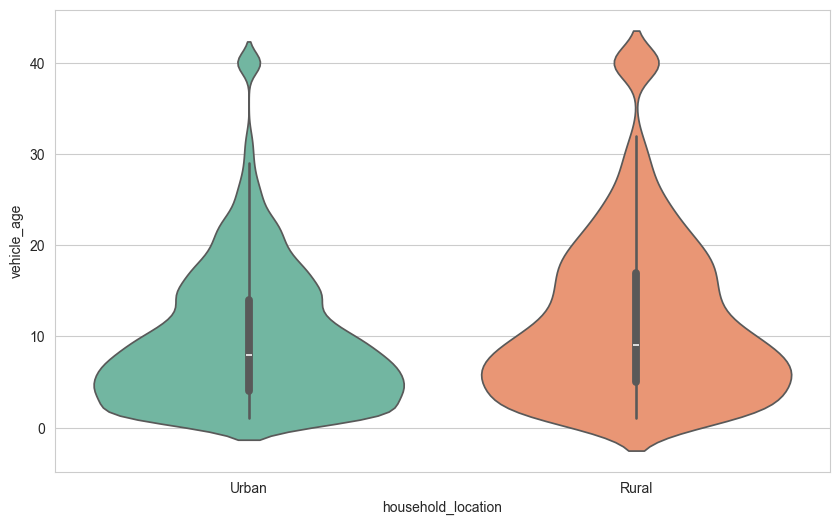

In [15]:
# Create a violin plot comparing vehicle age by household location (Urban vs Rural)
# seaborn's violinplot works very similarly to boxplot

## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize = (10,6))

## Step 2: use sns.violinplot with x='household_location' and y='vehicle_age'
# hint: you can add the argument inner='box' to show a mini boxplot inside the violin!
# use hue='household_location' and legend=False for coloring
sns.violinplot(data = nhts_data, x = 'household_location', y= 'vehicle_age', hue = 'household_location', palette = 'Set2')

## Step 3: add labels and title


## Step 4: show the plot
plt.show()

### Lab Activity #5: 
#1. Do Urban and Rural households have different vehicle age distributions?
#Yes, the violin charts illustrate older cars within rural communities. 
#2. Where is the peak of each distribution (the widest part of the violin)?
#For urban right around 5, and rural- slightly higher than that at about 7 or 8. 

#### Histogram

Histograms are graphs that also show the distribution of data, but only show the distribution of a single, continuous variable. Like boxplots, Python knows what histograms are, so if you give Python the variable you want to plot, Python knows to create 'bins' for the data and then count how many observations are in those bins. Note: Python will have a default number of bins based on your data size and shape, but you can change this if you want to see a specific breakdown of your data. Let's look at a histogram of `vehicle_age`.

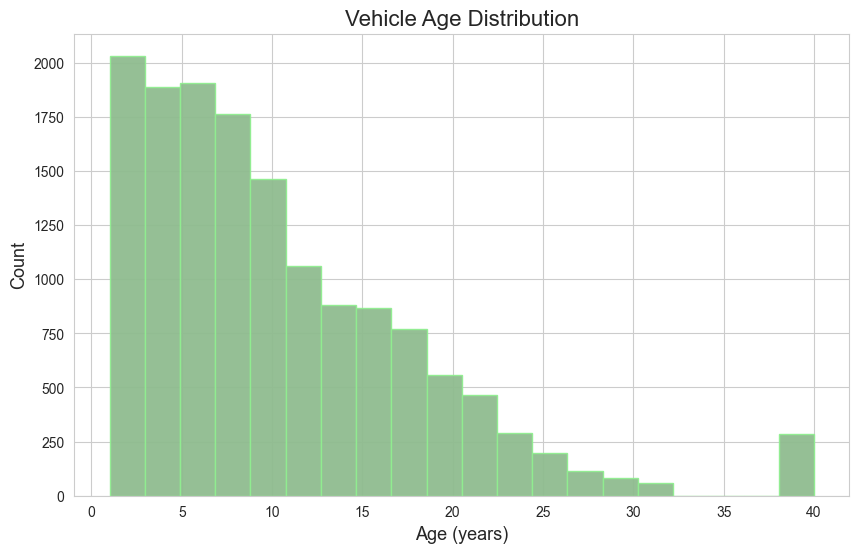

In [30]:
##Let's use matplotlib to create a histogram

##Tell Python you are plotting a figure and how big you want the figure to be
plt.figure(figsize = (10,6))

## Tell Python what type of plot you want. Here, .hist() creates a histogram
plt.hist(nhts_data['vehicle_age'], bins = 20, color ='darkseagreen', edgecolor = 'lightgreen', alpha = 0.95)

# Then let's label. You'll notice you can change the fontsize of all your labels!
plt.title('Vehicle Age Distribution', fontsize = 16)
plt.xlabel('Age (years)', fontsize = 13)
plt.ylabel('Count', fontsize = 13)


plt.show()

Awesome, we have a histogram! You'll notice that Python prints out the array that was used to create this plot above the plot. This tells you how Python created the 'bins' for data and what values are in each bin. This might be useful to have in a report when you need to report methods to a client.

Now let's try something more advanced — overlaying histograms for different groups. Let's compare vehicle age distribution between Urban and Rural households on the **same plot**.

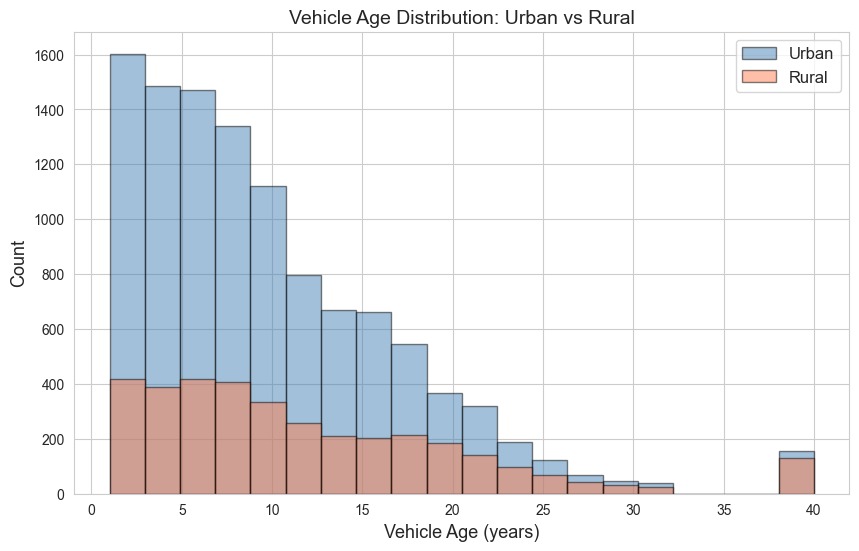

In [67]:
# Create overlapping histograms for Urban vs Rural vehicle ages
# We need to filter the data first, then plot each group separately

## Step 1: tell Python you are making a figure
plt.figure(figsize = (10,6))

## Step 2: filter and plot Urban vehicle ages
# hint: use nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
# use the alpha argument to make bars semi-transparent (e.g., alpha=0.5)
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
plt.hist(urban_ages, bins = 20, alpha = 0.5, label = 'Urban', color = 'steelblue', edgecolor = 'black')

## Step 3: filter and plot Rural vehicle ages on the same figure
rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(rural_ages, bins = 20, alpha = 0.5, label = 'Rural', color = 'coral', edgecolor = 'black')

## Step 4: add labels, title, and legend
plt.xlabel('Vehicle Age (years)', fontsize = 13)
plt.ylabel('Count', fontsize = 13)
plt.title('Vehicle Age Distribution: Urban vs Rural', fontsize = 14)
plt.legend(fontsize = 12)
plt.show()


### Lab Activity #6
Analyze the plots and state at least three different conclusions/information you gather
1.  Urban areas have a much higher total number of vehicles

2. Both urban and rural vehicles are concentrated in younger age ranges

3. Rural vehicles appear slightly older on average

#### Bar Plot

Barplots are really nice to look at categorical data and continuous data for either one or two variables, making them very versatile. With this variability comes some challenges though, so let's explore how to create multiple different bar plots below


Let's start with a **simple bar chart** showing the count of vehicles by fuel type. This is a good way to understand the composition of the vehicle fleet in the dataset.

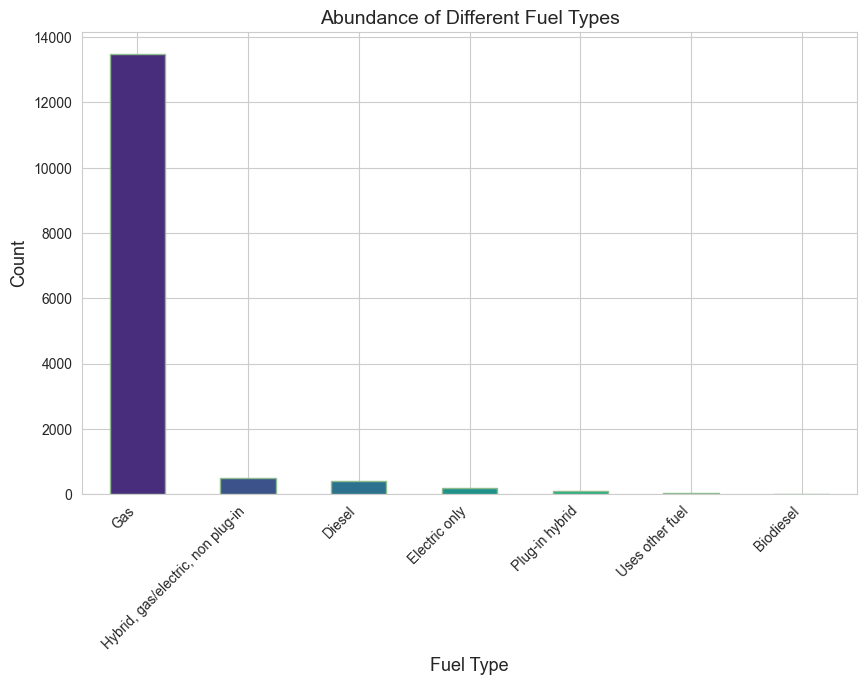

In [45]:
# Simple bar chart: count of vehicles by fuel type
# First we need to count the values, then plot

## Step 1: count the number of vehicles by fuel type
# hint: use .value_counts()
fuel_counts = nhts_data['fuel_type'].value_counts().dropna()

## Step 2: create the bar plot
plt.figure(figsize = (10,6))
fuel_counts.plot(kind = 'bar', edgecolor = 'darkseagreen', color = sns.color_palette('viridis', len(fuel_counts)))

## Step 3: add labels and customization
plt.xticks(rotation = 45, ha='right')

plt.xlabel('Fuel Type', fontsize = 13)
plt.ylabel('Count', fontsize = 13)
plt.title('Abundance of Different Fuel Types', fontsize = 14)

## Step 4: show the plot
plt.show()

Now let's try something more complex — a **stacked bar chart** that shows the number of each make of car by census_division. This requires some data grouping first. We need to tell Python what bars to be grouped by the make of the car. This means that we need to do a bit of data cleaning prior to actually being able to plot the data. Let's use the following space to group our data.

<Figure size 5000x1000 with 0 Axes>

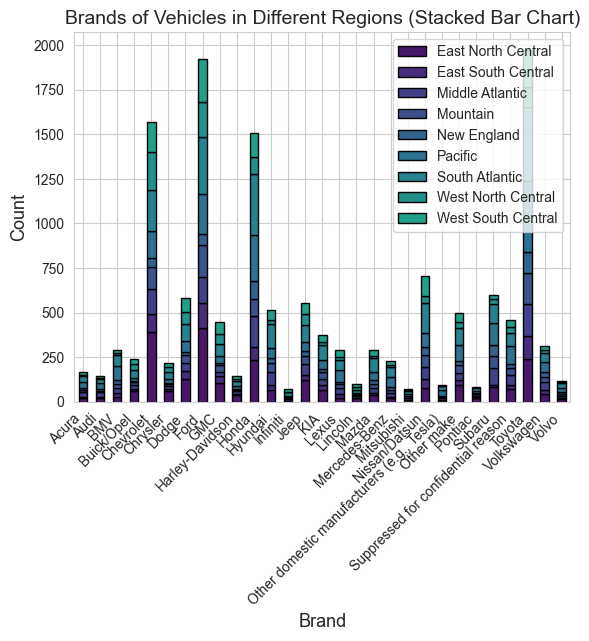

In [65]:
## let's customize our bar chart because our data right now isn't grouped correctly.

# Filter out NA values (assuming NA represents missing values)
nhts_data = nhts_data.dropna(subset=['make'])

# Grouping and counting by 'make' and 'census_division'
data_grouped = nhts_data.groupby(['make', 'census_division']).size().unstack(fill_value=0)
# Plotting
plt.figure(figsize=(50,10))
# Plotting stacked bar chart
data_grouped.plot(kind = 'bar', stacked = True, edgecolor = 'black', color = sns.color_palette('viridis', len('census_division')))

# Customizing the plot
plt.xlabel('Brand', fontsize = 13)
plt.ylabel('Count', fontsize = 13)
plt.title('Brands of Vehicles in Different Regions (Stacked Bar Chart)', fontsize = 14)
plt.xticks(rotation = 45, ha='right')

plt.legend(loc='upper right')

#Show the plot
plt.show()

Great, now we have a plot! But it doesn't really look so great, does it? Let's add some customizations below to move the legend and change up the colors.

In [ ]:
##let's customize our bar chart because our data right now isn't grouped correctly.

# Filter out NA values (assuming NA represents missing values)


# Plotting


# Grouping and counting by 'make' and 'census_division'


# Plotting stacked bar chart

# Customizing the plot


# Moving the legend outside the bounds of the plot


 # Adjust plot to make room for the legend

#Show the plot


#### Pie Chart

Pie charts are useful for showing the **proportion** of each category relative to the whole. They work best when you have a small number of categories (less than ~7). Let's create a pie chart showing the proportion of vehicle types in our dataset.

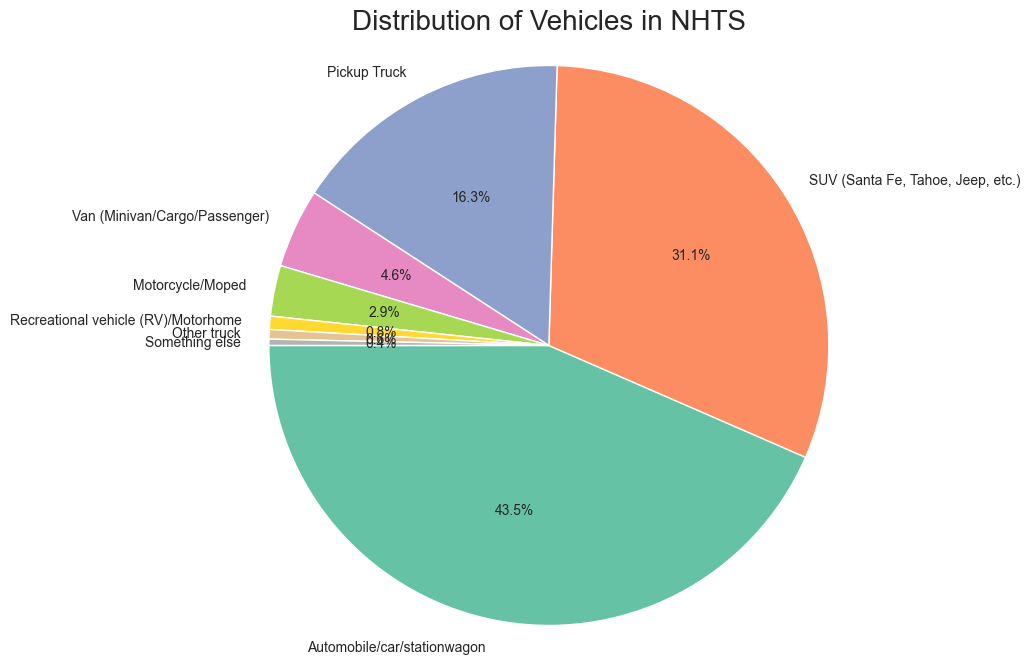

In [17]:
# Create a pie chart showing the proportion of each vehicle type

## Step 1: count the vehicles by type
type_counts = nhts_data['vehicle_type'].value_counts()

# hint: use .value_counts()
plt.figure(figsize=(10,8))

## Step 2: create the pie chart
# hint: use plt.pie() with arguments: labels=..., autopct='%1.1f%%', startangle=90
# autopct adds percentage labels to each slice

plt.pie(type_counts, startangle = 180, labels = type_counts.index, autopct = '%1.1f%%',
    colors = sns.color_palette('Set2', len(type_counts)),
        textprops = {'fontsize':10})

## Step 3: add title and make it look nice
# hint: plt.axis('equal') ensures the pie is a circle, not an ellipse
plt.axis('equal')
plt.title('Distribution of Vehicles in NHTS', fontsize = 20)
plt.show()


### Lab Activity #7
Analyze the pie chart:
1. What is the most common vehicle type?
Automobile/car/stationwagon
2. What percentage of the fleet are SUVs?
31.1% of the fleet are SUV's according to the Pie Chart.

#### Grouped Bar Chart

Sometimes we want to compare categories **side by side** rather than stacking them. A **grouped bar chart** places bars next to each other, making it easy to compare values across groups.

Let's compare the average number of vehicles per household between Urban and Rural areas, broken down by census region.

In [ ]:
# Grouped bar chart: average vehicles per household by census_region and household_location

## Step 1: group the data and calculate the mean
# hint: use nhts_data.groupby(['census_region', 'household_location'])['vehicles_per_household'].mean()
# then use .unstack() to pivot the data for plotting


## Step 2: plot as a grouped bar chart
# hint: use .plot(kind='bar') — without stacked=True, it will be grouped by default


## Step 3: add labels, title, legend


## Step 4: show the plot


### Lab Activity #8
Analyze the grouped bar chart:
1. Do Urban or Rural households tend to have more vehicles?

2. Which census region shows the biggest difference between Urban and Rural?


### Set Your Creativity Free


From the NHTS data, create different plots to help you visualize relationships between different data. Here are some ideas to get you started:
- How does household income relate to the number of vehicles?
- What is the distribution of vehicle year by fuel type?
- How does travel day vary between Urban and Rural households?
- Can you create a figure with **subplots** (multiple plots in one figure)?

Now for the fun stuff! Many of us like to make our graphs look really snappy with cool colors or features and Python lets you do that with many different built in functions from either the `matplotlib` package or the `seaborn` package. Below are some fun ideas for adding some customization to the plots you made above.

**Tip: Using Subplots**

Subplots allow you to place multiple plots in a single figure. This is very useful for comparing related visualizations side by side. Here is the basic structure:

```python
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# Plot on the first subplot
axes[0].hist(data1)
axes[0].set_title('Plot 1')

# Plot on the second subplot  
axes[1].hist(data2)
axes[1].set_title('Plot 2')

plt.tight_layout()
plt.show()
```

Try creating a subplot figure below!

In [ ]:
# Create a figure with subplots — try placing two or more plots side by side



First, let's go back to our boxplot and customize how the data is presented. There are two ways to customize your plots: (1) by changing how the data is grouped or called and (2) by changing aesthetic features on a graph such as color and font.  

Let's change data grouping or presentation first. This is where Python has a lot of power as a graphical tool since you don't have to rearrange your tables of data first; you can just add on functions to the data so that you can rerun your same graphical code and the graph will be generated again with the new data. We have to take care in how we present data, so make sure to check that any data alterations are correct before making a plot!